# **Preprocesamiento de textos en español con PLN**

En este proyecto se aplican técnicas básicas de Procesamiento del Lenguaje Natural (PLN) a un texto en español sobre aprendizaje profundo en medicina. Se realizan procesos de tokenización y lematización para preparar el texto para su análisis, evaluando además las limitaciones de herramientas diseñadas para inglés cuando se aplican al español.

**Objetivo:** aplicar técnicas básicas de PLN para limpiar y preparar textos en español y analizar los resultados obtenidos.

**Tecnologías usadas:**
 - Python
 - NLTK
 - WordNetLemmatizer
 - Tokenización y Lematización

 **Conclusión:** Se observa que herramientas como WordNetLemmatizer, optimizadas para inglés, presentan limitaciones al trabajar con textos en español, por lo que para PLN en español sería recomendable utilizar librerías como spaCy o Stanza.

## ▸	Instalación de bibliotecas necesarias:

In [ ]:
pip install nltk spacy pandas matplotlib

# **1. Preparación del entorno.**

## ▸	Preprocesamiento del texto. Tokenización y lematización:

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### **Selección de texto: Blog de divulgación sobre salud y tecnología**

He seleccionado un texto extraído de un blog de divulgación sobre salud y tecnología titulado: *"Aprendizaje profundo en medicina: Tecnología transformadora"*. Elegí este fragmento ya que aborda un tema que me resulta muy interesante.

> **APRENDIZAJE PROFUNDO EN EL PRONÓSTICO Y LA SUPERVIVENCIA DEL CÁNCER:** La predicción del pronóstico es un componente crucial de la oncología clínica, ya que puede influir en las decisiones de tratamiento basadas en el curso esperado de la enfermedad y la probabilidad de supervivencia. El aprendizaje profundo tiene la capacidad de calcular el pronóstico y la tasa de supervivencia de los pacientes cuando se utiliza mediante datos genómicos, transcriptómicos y otras formas de datos.


Dharani, L., & Victo Sudha George, G. (2025, marzo 3).
[*Aprendizaje profundo en medicina: Tecnología transformadora. Salud by Díaz.*](https://saludbydiaz.com/2025/03/03/aprendizaje-profundo-en-medicina-tecnologia-transformadora/)

Ahora vamos a realizar el preprocesamiento del texto. Para ello vamos a tokenizar y lematizar el texto.
- Tokenización: separar el texto en palabras o tokens.
- Lematización: reducir las palabras a su forma base o lema.

Primero lo realizarremos sobre el texto de prueba que nos indica el enunciado y seguidamente haremos el mismo procedimiento con el texto seleccionado anteriormente.

In [ ]:
texto_prueba = "El aprendizaje automático es una rama fascinante de la inteligencia artificial."
tokens_TP = word_tokenize(texto_prueba)
lematizador = WordNetLemmatizer()
lemas = [lematizador.lemmatize(token) for token in tokens_TP]
print(lemas)

['El', 'aprendizaje', 'automático', 'e', 'una', 'rama', 'fascinante', 'de', 'la', 'inteligencia', 'artificial', '.']


Vemos que simplemente se ha separado el texto en palabras, a excepción de 'es' que ha quedado como 'e'. Esto posiblemente es debido a que `WordNetLemmatizer` esta pensado para el ingles, no para el español.

Ahora haremos el mismo procedimiento con el texto seleccionado:

In [ ]:
texto = "APRENDIZAJE PROFUNDO EN EL PRONÓSTICO Y LA SUPERVIVENCIA DEL CÁNCER: La predicción del pronóstico es un componente crucial de la oncología clínica, ya que puede influir en las decisiones de tratamiento basadas en el curso esperado de la enfermedad y la probabilidad de supervivencia. El aprendizaje profundo tiene la capacidad de calcular el pronóstico y la tasa de supervivencia de los pacientes cuando se utiliza mediante datos genómicos, transcriptómicos y otras formas de datos."

#Tokenizadcion
tokens_AP = word_tokenize(texto)

# Lematizacion con WordNetLemmatizer
lematizador = WordNetLemmatizer()
lemas = [lematizador.lemmatize(tokens) for tokens in tokens_AP]
print("\n Lemas WordNetLemmatizer:")
print(lemas)

# Lematización con


 Lemas WordNetLemmatizer:
['APRENDIZAJE', 'PROFUNDO', 'EN', 'EL', 'PRONÓSTICO', 'Y', 'LA', 'SUPERVIVENCIA', 'DEL', 'CÁNCER', ':', 'La', 'predicción', 'del', 'pronóstico', 'e', 'un', 'componente', 'crucial', 'de', 'la', 'oncología', 'clínica', ',', 'ya', 'que', 'puede', 'influir', 'en', 'la', 'decisiones', 'de', 'tratamiento', 'basadas', 'en', 'el', 'curso', 'esperado', 'de', 'la', 'enfermedad', 'y', 'la', 'probabilidad', 'de', 'supervivencia', '.', 'El', 'aprendizaje', 'profundo', 'tiene', 'la', 'capacidad', 'de', 'calcular', 'el', 'pronóstico', 'y', 'la', 'tasa', 'de', 'supervivencia', 'de', 'los', 'pacientes', 'cuando', 'se', 'utiliza', 'mediante', 'datos', 'genómicos', ',', 'transcriptómicos', 'y', 'otras', 'formas', 'de', 'datos', '.']


Vemos que ocurre lo mismo, el texto está bien separado por palabras, pero no se ha lematizado correctamente, seguramente sea debido al mismo tema, `WordNetLemmatizer` esta pensado para el ingles, no para el español.

He estado investigando y para NLTK no existe un lematizador en español, el que funcionan en nuestro idioma es el lematizador de SpaCy.

## ▸	Reconocimiento de entidades nombradas (NER) utilizando SpaCy:

In [ ]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 34.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Ahora vamos a lematizar de nuevo el texto con SpaCy para ver si funciona mejor que NLTK y vamos a hacer el reconocimiento de entidades.

In [ ]:
import spacy
nlp = spacy.load("es_core_news_sm")

doc = nlp(texto)

print("Lematización con SpaCy:")
lemas_texto = [f"{token.text} -> {token.lemma_}" for token in doc]
print(lemas_texto)

print("\n")

print("Reconocimiento de entidades con SpaCy:")
for entidad in doc.ents:
  print(entidad.text, '->', entidad.label_)

Lematización con SpaCy:
['APRENDIZAJE -> aprendizaje', 'PROFUNDO -> profundo', 'EN -> EN', 'EL -> el', 'PRONÓSTICO -> PRONÓSTICO', 'Y -> Y', 'LA -> el', 'SUPERVIVENCIA -> SUPERVIVENCIA', 'DEL -> DEL', 'CÁNCER -> CÁNCER', ': -> :', 'La -> el', 'predicción -> predicción', 'del -> del', 'pronóstico -> pronóstico', 'es -> ser', 'un -> uno', 'componente -> componente', 'crucial -> crucial', 'de -> de', 'la -> el', 'oncología -> oncología', 'clínica -> clínico', ', -> ,', 'ya -> ya', 'que -> que', 'puede -> poder', 'influir -> influir', 'en -> en', 'las -> el', 'decisiones -> decisión', 'de -> de', 'tratamiento -> tratamiento', 'basadas -> basado', 'en -> en', 'el -> el', 'curso -> curso', 'esperado -> esperado', 'de -> de', 'la -> el', 'enfermedad -> enfermedad', 'y -> y', 'la -> el', 'probabilidad -> probabilidad', 'de -> de', 'supervivencia -> supervivencia', '. -> .', 'El -> el', 'aprendizaje -> aprendizaje', 'profundo -> profundo', 'tiene -> tener', 'la -> el', 'capacidad -> capacidad',

**Lematización**

Podemos observar que en general la lematización con SpaCy funciona bien en español ya que normaliza verbos correctamente ("es" -> "ser"), los determinantes los pasa a su forma base ("la/las/los" -> "el") y pasa de plural a singular ("decisiones" -> "decisión"). Es mucho más eficiente que la lematización que ofrece NLTK ya que no esta diseñada para español.


**Reconocimiento de entidades**

El modelo únicamente reconoce aquellas entidades que aparecen en mayúscula y, además, las clasifica de forma erronea. A continuación, relizaremos una prueba pasando el texto a minusculas (utilizando la función `.lower()`  al final del texto) para observas si logra reconocer correctamente alguna entidad o si produce algún cambio en los resultados.

In [ ]:
texto_min = "APRENDIZAJE PROFUNDO EN EL PRONÓSTICO Y LA SUPERVIVENCIA DEL CÁNCER: La predicción del pronóstico es un componente crucial de la oncología clínica, ya que puede influir en las decisiones de tratamiento basadas en el curso esperado de la enfermedad y la probabilidad de supervivencia. El aprendizaje profundo tiene la capacidad de calcular el pronóstico y la tasa de supervivencia de los pacientes cuando se utiliza mediante datos genómicos, transcriptómicos y otras formas de datos.".lower()

In [ ]:
import spacy
nlp = spacy.load("es_core_news_sm")

doc = nlp(texto_min)
for entidad in doc.ents:
  print(entidad.text, '->', entidad.label_)

Podemos observar que el modelo `es_core_news_sm` no reconoce correctamente las entidades, debido a que ha sido entrenado principalemnte con textos generales o noticias, limitando su desempeño en dominios especializados como el científico.

Para evaluar mejor su funcionamiento, vamos a seleccionar un fragmento de texto más general.

### **Selección de texto: Noticia Mundo Deportivo**

Ahora vamos a probar con un texto extraido de una noticia publicada en el Mundo Deportivo:

> La redacción de Mundo Deportivo ha elogiado la valiosa y sufrida victoria del FC Barcelona sobre el Real Madrid en una final de Copa del Rey que quedará grabada en la memoria de los aficionados. El equipo de Hansi Flick supo reponerse a la remontada blanca, primero adelantándose con un golazo de Pedri y luego igualando el marcador gracias a Ferran Torres para forzar una prórroga donde Jules Koundé, con un disparo lejano, selló el triunfo en el minuto 116.

— Mundo Deportivo. (2025, abril 27). [*Análisis exprés: el Barça gana una final épica ante el Real Madrid*](https://www.mundodeportivo.com/futbol/fc-barcelona/20250427/1002453014/analisis-expres-barca-gana-final-epica-real-madrid.html)

Hemos modificado ligeramente texto añadiendo la expresión *"Estadio La Cartuja de Sevilla"* para comprobar si el modelo es capaz de identificarla correctamente.

Ahora vamos a probar el modelo `es_core_news_lg`, la versión más grabde de spaCy en español, para comprobar si un modelo más entrenado y con mayor cantidad de datos es capaz de reconocer correctamente las entidades presentes en el texto.



In [ ]:
texto_MD = "La redacción de Mundo Deportivo ha elogiado la valiosa y sufrida victoria del FC Barcelona sobre el Real Madrid en una final de Copa del Rey, disputada en el Estadio La Cartuja de Sevilla, que quedará grabada en la memoria de los aficionados. El equipo de Hansi Flick supo reponerse a la remontada blanca, primero adelantándose con un golazo de Pedri y luego igualando el marcador gracias a Ferran Torres para forzar una prórroga donde Jules Koundé, con un disparo lejano, selló el triunfo en el minuto 116."

In [ ]:
!python -m spacy download es_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 905.9 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load("es_core_news_lg")

doc = nlp(texto_MD)
for entidad in doc.ents:
  print(entidad.text, '->', entidad.label_)

Mundo Deportivo -> ORG
FC Barcelona -> ORG
Real Madrid -> ORG
Copa del Rey -> MISC
Estadio La Cartuja de Sevilla -> LOC
El equipo de Hansi Flick -> MISC
Pedri -> PER
Ferran Torres -> PER
Jules Koundé -> PER


Podemos observar que en este caso el modelo ha reconocido correctamente la mayoria de los nombres de personas (PER), de organizaciones deportivas (ORG) y también la localización (LOC). *"Copa del rey"* la etiqueta como MISC, lo que indica que no se clasifica dentro de las categorías principales (persona, organización o lugar), sino como una entidad miscelánea, utilizada para competiciones o eventos generales. Sin embargo sigue presentando algunas imprecisiones como en el caso de *"El equipo de Hansi Flick"*, donde debería haber identificado *"Hansi Flick"* como una entidad de tipo persona y el resto como un complemento contextual.


## ▸	Diseño del pipeline.

Creación de un flujo automatizado para el análisis completo del texto:

In [ ]:

def pipeline(text):                 # Definimos la función pipeline
    # Limpieza y tokenización
    tokens_MD = word_tokenize(text)    # Tokenización
    lemas = [lematizador.lemmatize(token) for token in tokens_MD]    # Lematizacion con WordNetLemmatizier (ingles)

    # Reconocimiento de Entidades Nombradas (NER) con SpaCy
    doc = nlp(" ".join(lemas))      # Unimos los lemas en una cadena de texto para poder procesarla
    entidades = [(ent.text, ent.label_) for ent in doc.ents]      # Extraemos las entidades en una lista de tuplas

    return lemas, entidades         # Devolvemos los lemas y las entidades

resultado = pipeline(texto_MD)      # Ejecutamos el pipline sobre el texto del Mundo Deportivo

tokens_MD = word_tokenize(texto_MD)

print("Tokens:", tokens_MD)
print("Lemas:", resultado[0])       # Lista de lemas obtenidos
print("Entidades:", resultado[1])   # Lista de entidades reconocidas

Tokens: ['La', 'redacción', 'de', 'Mundo', 'Deportivo', 'ha', 'elogiado', 'la', 'valiosa', 'y', 'sufrida', 'victoria', 'del', 'FC', 'Barcelona', 'sobre', 'el', 'Real', 'Madrid', 'en', 'una', 'final', 'de', 'Copa', 'del', 'Rey', ',', 'disputada', 'en', 'el', 'Estadio', 'La', 'Cartuja', 'de', 'Sevilla', ',', 'que', 'quedará', 'grabada', 'en', 'la', 'memoria', 'de', 'los', 'aficionados', '.', 'El', 'equipo', 'de', 'Hansi', 'Flick', 'supo', 'reponerse', 'a', 'la', 'remontada', 'blanca', ',', 'primero', 'adelantándose', 'con', 'un', 'golazo', 'de', 'Pedri', 'y', 'luego', 'igualando', 'el', 'marcador', 'gracias', 'a', 'Ferran', 'Torres', 'para', 'forzar', 'una', 'prórroga', 'donde', 'Jules', 'Koundé', ',', 'con', 'un', 'disparo', 'lejano', ',', 'selló', 'el', 'triunfo', 'en', 'el', 'minuto', '116', '.']
Lemas: ['La', 'redacción', 'de', 'Mundo', 'Deportivo', 'ha', 'elogiado', 'la', 'valiosa', 'y', 'sufrida', 'victoria', 'del', 'FC', 'Barcelona', 'sobre', 'el', 'Real', 'Madrid', 'en', 'una', '

En este pipeline realizamos primero una limpieza del texto aplicando la tokenización para dividir el texto en palabras, para ello aplicamos la función `word_tokenize()` al texto. A continuación realizamos la lematización coon WordNetLemmatizer (así lo indica el enunciado). Tal y como comentábamos anteriormente, el lematizador no está entrenado específicamente para el español, es por esto que la mayoría de las palabras se mantienen iguales a excepción de algunos plurales que sí consigue normalizar.

Una vez tenemos los lemas, los unimos en una cadena de texto para que SpaCy pueda procesarla y reconocer las entidades. En este ejemplo el resultado es bastante preciso y similar al obtenido previamente a partir del modelo `es_core_news_lg`.

# **2.	Visualización de resultados**

## ▸	Gráficos de distribución de tokens:

Este tipo de gráfico muestra cómo se reparten la longitudes de palabras (tokens) en un texto. Cuenta los caracteres de cada palabra y los agrupa en diferentes intervalos de longitud.

Se usa para ver si el texto contiene palabras cortas como artículos o preposiciones, palabras largas más técnicas o descriptivas o una mezcla equilibrada. Esto ayuda a identificar el tipo de texto si es mas técnico a por el cobtratio si es más generico, resulta muy útil para entender la complejidad léxica del texto.

#### Texto de prueba

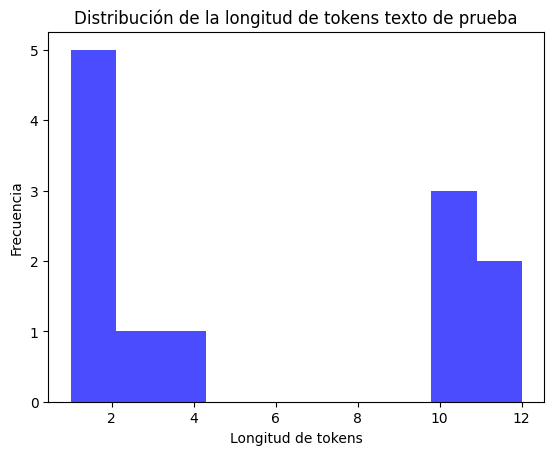

In [ ]:
import matplotlib.pyplot as plt

plt.hist([len(token) for token in tokens_TP], bins=10, color='blue', alpha=0.7)
plt.title('Distribución de la longitud de tokens texto de prueba')
plt.xlabel('Longitud de tokens')
plt.ylabel('Frecuencia')
plt.show()

En el texto de prueba, el histograma muestra pocas palabras y la mayoría son cortas, esto suele indicar que se trata de un texto sencillo. Aun así, aparecen algunas palabras más largas y técnicas que también se pueden ver reflejadas en la distribución.

### Texto de divulgación sobre salud y tecnología

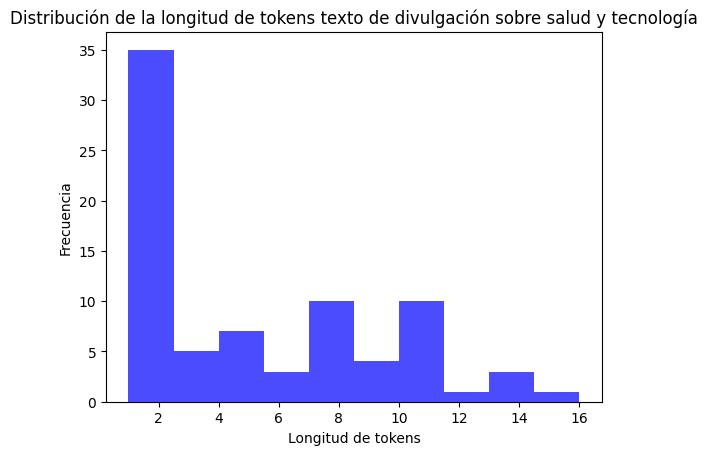

In [ ]:
import matplotlib.pyplot as plt

plt.hist([len(token) for token in tokens_AP], bins=10, color='blue', alpha=0.7)
plt.title('Distribución de la longitud de tokens texto de divulgación sobre salud y tecnología')
plt.xlabel('Longitud de tokens')
plt.ylabel('Frecuencia')
plt.show()

En este histograma podemos apreciar la presencia de términos técnicos como *transcriptómicos* o *genómicos*, lo que genera un mayor número de tokens largos y da lugar a palabras con longitudes que alcanzan entre 14 y 16 caracteres.

### Texto del Mundo Deportivo

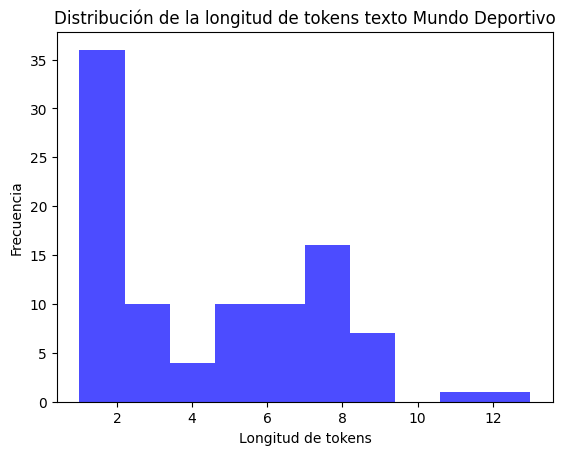

In [ ]:
import matplotlib.pyplot as plt

plt.hist([len(token) for token in tokens_MD], bins=10, color='blue', alpha=0.7)
plt.title('Distribución de la longitud de tokens texto Mundo Deportivo')
plt.xlabel('Longitud de tokens')
plt.ylabel('Frecuencia')
plt.show()

Por último, el texto del Mundo Deportivo presenta una distribución más equilibrada entre palabras cortas y medianas, aunque también tiene algún token largo. La mayor parte del vocabulario corresponde a descripciones y nombres propios, lo que produce una gráfica similar a la del texto de divulgación sobre salud, pero con menos variación en las longitudes máximas.

### Conclusión histogramas

Los histogramas permiten comparar de forma visual el tipo de vocabulario empleado en un texto: uno muy básico y corto aunque con alguna palabra técnica, otro altamente técnico y por último, uno periodístico con varios nombres propios.

# Conclusiones

El análisis muestra que WordNetLemmatizer no funciona correctamente en español al estar optimizado para inglés. Para PLN en español se recomienda utilizar herramientas como spaCy o Stanza, que ofrecen mejores resultados en lematización y análisis lingüístico.